# Predicción de Precios de Autos Usados
## Trabajo Final — Aprendizaje de Máquina


| Campo | Detalle |
|---|---|
| **Materia** | Aprendizaje de Máquina |
| **Institución** | Laboratorio de Sistemas Embebidos - Facultad de Ingeniería — UBA |
| **Dataset** | [Vehicle dataset](https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho/data) — Kaggle |

## Integrantes

| Integrante | Legajo |
|---|---|
| Marcos Lund | a2408 |
| Tomás Mc Nally | a2420 |
| Alan Vignolo | a2418 |
| Agustin Biancardi | a2403 |

## Fuente de datos

El conjunto **Vehicle Dataset from CarDekho** reúne anuncios de automóviles usados en India: marca, modelo, año o antigüedad, kilometraje, tipo de combustible, transmisión, ubicación y otras variables técnicas y comerciales. Sirve para estudiar el mercado de usados y para tareas de **predicción de precio** mediante aprendizaje automático.

**Referencia:** [Vehicle Dataset from CarDekho (Kaggle)](https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho)

## Introducción

Este trabajo aborda un problema de **regresión supervisada**: estimar el precio de venta (`Price`) a partir de atributos del vehículo y del anuncio. Se busca caracterizar cómo se relacionan el precio con la **antigüedad** del auto, el **kilometraje**, la **marca** y el resto de las covariables disponibles, y contrastar distintos enfoques de modelado sobre un pipeline reproducible.

### ¿Por qué este problema?

El mercado de autos usados opera con alta asimetría de información: vendedores y compradores frecuentemente no tienen una referencia objetiva del valor de mercado de un vehículo. Un modelo predictivo robusto puede:

- Asistir a vendedores a fijar precios competitivos basados en características objetivas.
- Ayudar a compradores a detectar sobreprecios o gangas respecto al mercado.
- Servir como motor para plataformas de valuación automática (fintech, aseguradoras, concesionarios).

### Preguntas de investigación

1. ¿Es posible predecir el precio de un auto usado con alta precisión a partir de sus características físicas, mecánicas y comerciales?
2. ¿Qué familia de algoritmos de ML (lineal, basada en árboles) ofrece el mejor rendimiento para este problema de regresión?
3. ¿Aporta la reducción de dimensionalidad via PCA algún beneficio en un dataset de estas dimensiones (~100:1 filas/columnas)?
4. ¿Cuánto mejora el rendimiento al optimizar hiperparámetros frente a los valores por defecto?

### Objetivo Principal
Desarrollar un modelo predictivo que logre estimar el precio de venta apropiado dada las características de un vehículo

### Objetivos Específicos
- Explorar y preparar los datos
- Aplicar y comparar varios modelos de regresión
- Evaluar el desempeño con métricas adecuadas para variables continuas
- Sintetizar resultados junto con una reflexión sobre mejoras posibles.

### Hipótesis de negocio iniciales de trabajo
- Esperamos encontrar que autos más nuevos y con menor kilometraje tenderán a precios más altos
- Esperamos detectar comportamientos de precio relacionados dentro de una misma marca
- El tipo de combustible y transmisión podrían asociarse a distintos rangos de precio.

### Hipótesis técnicas iniciales de trabajo

- Los modelos basados en ensambles de árboles (Random Forest, XGBoost, LightGBM) superarán a los modelos lineales, ya que se espera una relación precio-características del tipo no lineal (depreciación por kilometraje, depreciación por edad).
- PCA no aportará mejoras dado que el dataset no es de alta dimensionalidad y las features ingenierizadas son mayormente independientes.
- El ajuste de hiperparámetros mejorará la performance, especialmente reduciendo el overfitting del árbol de decisión individual.

La reproducibilidad del análisis se apoya en el código versionado, rutas relativas al repositorio y un orden de pasos que separa la preparación de datos del entrenamiento y la evaluación.

## Selección de la versión del dataset

En la carpeta `datasets` hay cuatro archivos que corresponden a versiones sucesivas del mismo origen: `CAR DETAILS FROM CAR DEKHO.csv`, `car data.csv`, `Car details v3.csv` y `car_details_v4.csv`. Se utiliza **`car_details_v4.csv`** como tabla principal porque es la que reúne el **mayor número de columnas**, lo que aporta más información para el modelado aun cuando no sea necesariamente la versión con más filas.

A continuación se resume el tamaño de cada archivo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from datetime import datetime
from pathlib import Path

DATASETS_DIR = Path('../datasets')
VERSION_FILES = [
    'CAR DETAILS FROM CAR DEKHO.csv',
    'car data.csv',
    'Car details v3.csv',
    'car_details_v4.csv',
]

for name in VERSION_FILES:
    path = DATASETS_DIR / name
    try:
        d = pd.read_csv(path)
    except UnicodeDecodeError:
        d = pd.read_csv(path, encoding='latin-1')
    print(f'{name}: {d.shape[0]} filas, {d.shape[1]} columnas')

df_base = pd.read_csv(DATASETS_DIR / 'car_details_v4.csv')

CAR DETAILS FROM CAR DEKHO.csv: 4340 filas, 8 columnas
car data.csv: 301 filas, 9 columnas
Car details v3.csv: 8128 filas, 13 columnas
car_details_v4.csv: 2059 filas, 20 columnas


## Análisis Exploratorio de Datos

Se examina la estructura del conjunto (dimensiones, tipos, valores representativos), la distribución de variables numéricas y categóricas, la presencia de datos faltantes y valores extremos, y su relación con el precio de venta.

In [2]:
df_base.head()

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0


In [3]:
df_base.shape

(2059, 20)

In [4]:
df_base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                2059 non-null   object 
 1   Model               2059 non-null   object 
 2   Price               2059 non-null   int64  
 3   Year                2059 non-null   int64  
 4   Kilometer           2059 non-null   int64  
 5   Fuel Type           2059 non-null   object 
 6   Transmission        2059 non-null   object 
 7   Location            2059 non-null   object 
 8   Color               2059 non-null   object 
 9   Owner               2059 non-null   object 
 10  Seller Type         2059 non-null   object 
 11  Engine              1979 non-null   object 
 12  Max Power           1979 non-null   object 
 13  Max Torque          1979 non-null   object 
 14  Drivetrain          1923 non-null   object 
 15  Length              1995 non-null   float64
 16  Width 

### Conversión de variables

Se define la antigüedad del auto a partir del año, se tipifican variables categóricas de baja cardinalidad y se normalizan campos numéricos almacenados como texto (por ejemplo cilindrada y potencia) para poder resumirlos y graficarlos con consistencia.

Se crea una columna `Age` en base a `Year`, la cual se elimina.

In [5]:
# Creación de nuevas columnas
current_year = datetime.now().year
df_base['Age'] = current_year - df_base['Year']
df_base.drop(columns=['Year'], inplace=True)

Convertimos columnas de tipo `string` con pocos valores distintos (`unique`) al tipo `category`.

In [6]:
df_base['Make'] = df_base['Make'].astype('category')
df_base['Fuel Type'] = df_base['Fuel Type'].astype('category')
df_base['Transmission'] = df_base['Transmission'].astype('category')
df_base['Location'] = df_base['Location'].astype('category')
df_base['Color'] = df_base['Color'].astype('category')
df_base['Owner'] = df_base['Owner'].astype('category')
df_base['Seller Type'] = df_base['Seller Type'].astype('category')
df_base['Drivetrain'] = df_base['Drivetrain'].astype('category')

Convertimos columnas de tipo string a numéricas:
- Para `Engine` se extrae el número de cilindrada (ej: `"1984 cc"` --> `1984`)
- Para `Max Power` se extrae el número de caballos de fuerza (ej: `"188 bhp @ 4200 rpm"` --> `188`)
- Para `Max Torque` se extrae el número de Newton-metros (ej: `"320 Nm @ 1500 rpm"` --> `320`)

In [7]:
df_base['Engine'] = df_base['Engine'].str.extract(r'(\d+)').astype(float)
df_base['Max Power'] = df_base['Max Power'].str.extract(r'(\d+\.?\d*)').astype(float)
df_base['Max Torque'] = df_base['Max Torque'].str.extract(r'(\d+\.?\d*)').astype(float)

In [8]:
df_base.head()

,Make,Model,Price,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity,Age
0,Honda,Amaze 1.2 VX i-VTEC,505000,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198.0,87.0,109.0000,FWD,3990.0,1680.0,1505.0,5.0,35.0,9
1,Maruti Suzuki,Swift DZire VDI,450000,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248.0,74.0,190.0000,FWD,3995.0,1695.0,1555.0,5.0,42.0,12
2,Hyundai,i10 Magna 1.2 Kappa2,220000,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197.0,79.0,112.7619,FWD,3585.0,1595.0,1550.0,5.0,35.0,15
3,Toyota,Glanza G,799000,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197.0,82.0,113.0000,FWD,3995.0,1745.0,1510.0,5.0,37.0,7
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393.0,148.0,343.0000,RWD,4735.0,1830.0,1795.0,7.0,55.0,8


In [9]:
df_base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Make                2059 non-null   category
 1   Model               2059 non-null   object  
 2   Price               2059 non-null   int64   
 3   Kilometer           2059 non-null   int64   
 4   Fuel Type           2059 non-null   category
 5   Transmission        2059 non-null   category
 6   Location            2059 non-null   category
 7   Color               2059 non-null   category
 8   Owner               2059 non-null   category
 9   Seller Type         2059 non-null   category
 10  Engine              1979 non-null   float64 
 11  Max Power           1979 non-null   float64 
 12  Max Torque          1979 non-null   float64 
 13  Drivetrain          1923 non-null   category
 14  Length              1995 non-null   float64 
 15  Width               1995 non-null   fl

In [10]:
df_base.describe()

,Price,Kilometer,Engine,Max Power,Max Torque,Length,Width,Height,Seating Capacity,Fuel Tank Capacity,Age
count,2.059000e+03,2.059000e+03,1979.000000,1979.000000,1979.000000,1995.000000,1995.000000,1995.000000,1995.000000,1946.000000,2059.000000
mean,1.702992e+06,5.422471e+04,1692.575543,129.611774,245.851019,4280.860652,1767.991980,1591.735338,5.306266,52.002210,9.574551
std,2.419881e+06,5.736172e+04,643.736294,65.073797,140.465731,442.458507,135.265825,136.073956,0.822170,15.110198,3.363564
min,4.900000e+04,0.000000e+00,624.000000,35.000000,48.000000,3099.000000,1475.000000,1165.000000,2.000000,15.000000,4.000000
25%,4.849990e+05,2.900000e+04,1197.000000,83.000000,115.000000,3985.000000,1695.000000,1485.000000,5.000000,41.250000,7.000000
50%,8.250000e+05,5.000000e+04,1498.000000,116.000000,200.000000,4370.000000,1770.000000,1545.000000,5.000000,50.000000,9.000000
75%,1.925000e+06,7.200000e+04,1995.000000,171.000000,350.000000,4629.000000,1831.500000,1675.000000,5.000000,60.000000,12.000000
max,3.500000e+07,2.000000e+06,6592.000000,660.000000,780.000000,5569.000000,2220.000000,1995.000000,8.000000,105.000000,38.000000


### Análisis de variables numéricas

Se revisan escalas, dispersión y forma de las distribuciones, y su vínculo con el precio mediante histogramas, boxplots y correlaciones.

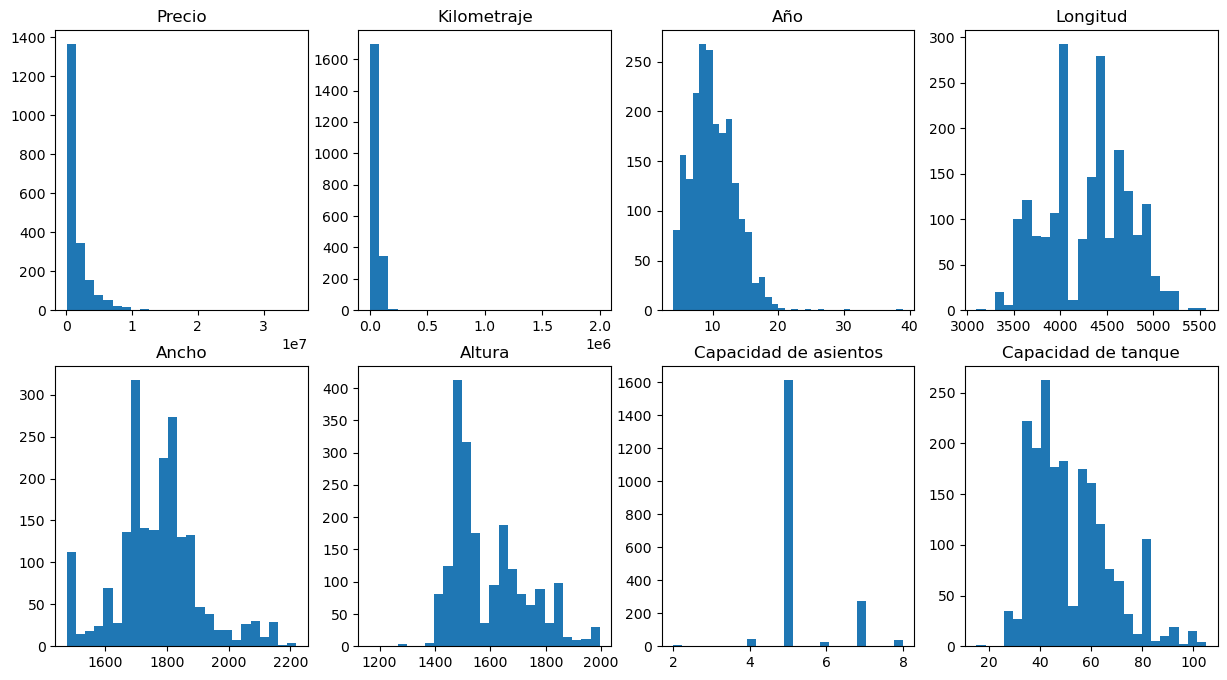

In [11]:
fig, ax = plt.subplots(2, 4, figsize=(15, 8))

ax[0,0].hist(df_base['Price'], bins=25)
ax[0,0].set_title('Precio')
ax[0,1].hist(df_base['Kilometer'], bins=25)
ax[0,1].set_title('Kilometraje')
ax[0,2].hist(df_base['Age'], bins=np.arange(df_base['Age'].min(), df_base['Age'].max() + 2))
ax[0,2].set_title('Año')
ax[0,3].hist(df_base['Length'], bins=25)
ax[0,3].set_title('Longitud')
ax[1,0].hist(df_base['Width'], bins=25)
ax[1,0].set_title('Ancho')
ax[1,1].hist(df_base['Height'], bins=25)
ax[1,1].set_title('Altura')
ax[1,2].hist(df_base['Seating Capacity'], bins=25)
ax[1,2].set_title('Capacidad de asientos')
ax[1,3].hist(df_base['Fuel Tank Capacity'], bins=25)
ax[1,3].set_title('Capacidad de tanque')

plt.show()


### Análisis de variables categóricas

Se analizan frecuencias y composición de categorías; donde hace falta se agrupan niveles poco frecuentes o se homogeneizan etiquetas para estabilizar el modelado posterior.

In [12]:
df_base.describe(include='category')

,Make,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Drivetrain
count,2059,2059,2059,2059,2059,2059,2059,1923
unique,33,9,2,77,17,6,3,3
top,Maruti Suzuki,Diesel,Manual,Mumbai,White,First,Individual,FWD
freq,440,1049,1133,342,802,1619,1997,1330


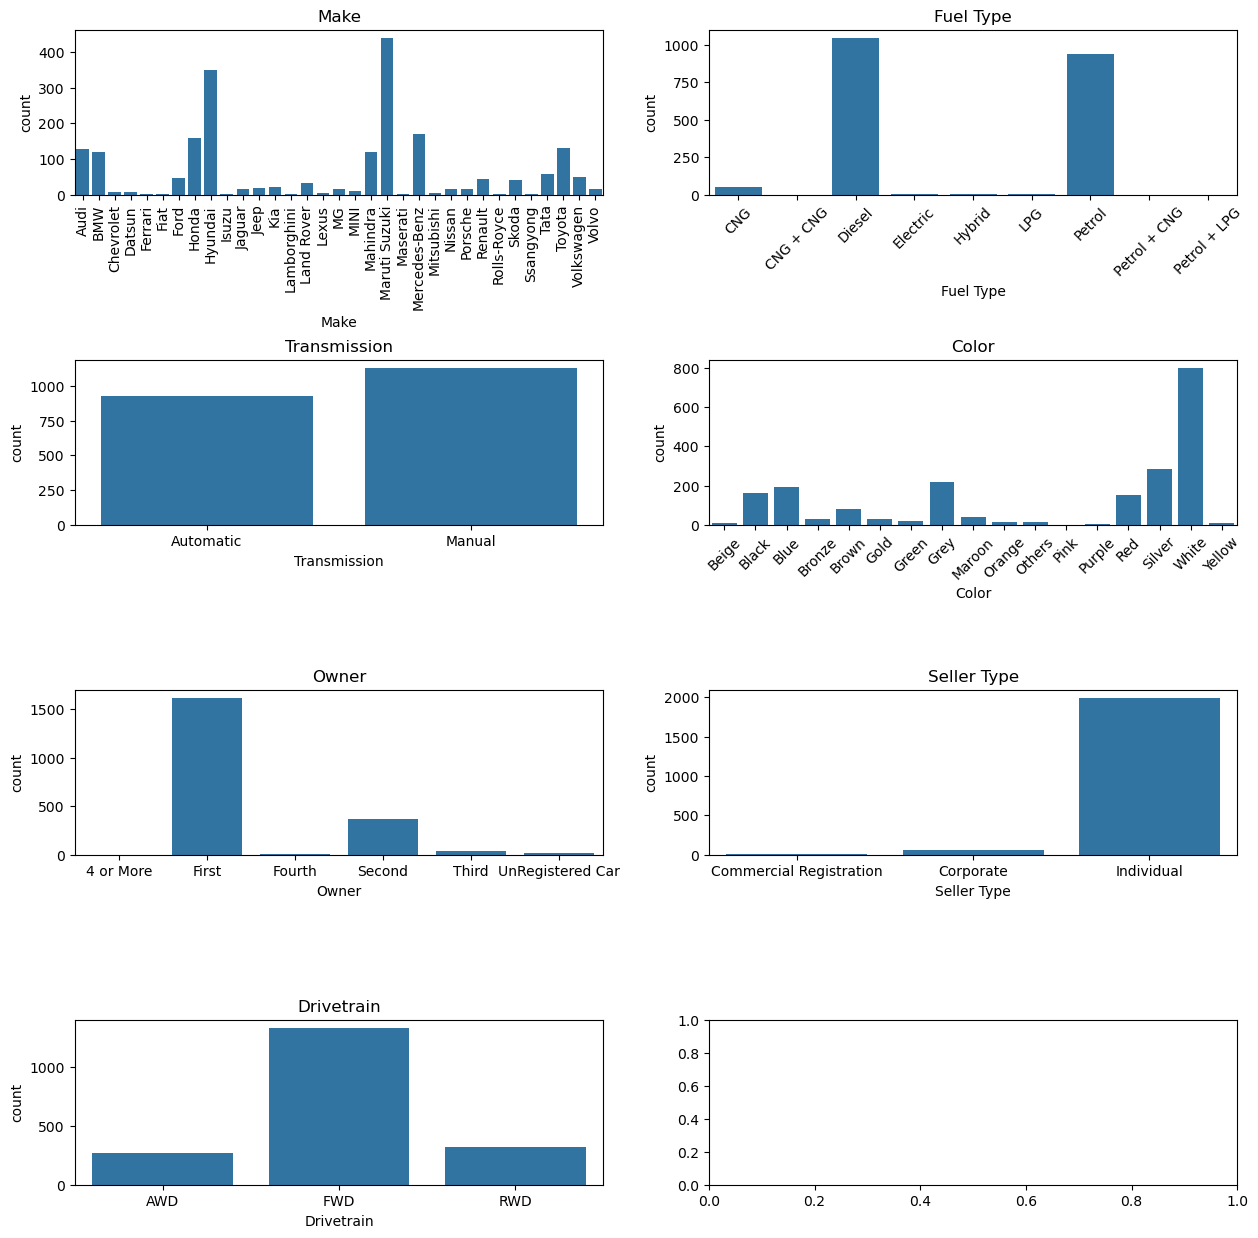

In [13]:
fig, ax = plt.subplots(4, 2, figsize=(15, 15))

# Gráficos de barras
sns.countplot(x='Make', data=df_base, ax=ax[0,0])
sns.countplot(x='Fuel Type', data=df_base, ax=ax[0,1])
sns.countplot(x='Transmission', data=df_base, ax=ax[1,0])
sns.countplot(x='Color', data=df_base, ax=ax[1,1])
sns.countplot(x='Owner', data=df_base, ax=ax[2,0])
sns.countplot(x='Seller Type', data=df_base, ax=ax[2,1])
sns.countplot(x='Drivetrain', data=df_base, ax=ax[3,0])

# Títulos
ax[0,0].set_title('Make')
ax[0,1].set_title('Fuel Type')
ax[1,0].set_title('Transmission')
ax[1,1].set_title('Color')
ax[2,0].set_title('Owner')
ax[2,1].set_title('Seller Type')
ax[3,0].set_title('Drivetrain')

ax[0,0].tick_params(axis='x', rotation=90)
ax[0,1].tick_params(axis='x', rotation=45)
ax[1,1].tick_params(axis='x', rotation=45)

plt.subplots_adjust(hspace=1)

plt.show()

In [14]:
# Conteo de "Fuel Type"
df_base['Fuel Type'].value_counts()

Fuel Type
Diesel          1049
Petrol           942
CNG               50
Electric           7
LPG                5
Hybrid             3
CNG + CNG          1
Petrol + CNG       1
Petrol + LPG       1
Name: count, dtype: int64

#### `Fuel Type`

In [15]:
# Conteo de "Fuel Type"
df_base['Fuel Type'].value_counts()

Fuel Type
Diesel          1049
Petrol           942
CNG               50
Electric           7
LPG                5
Hybrid             3
CNG + CNG          1
Petrol + CNG       1
Petrol + LPG       1
Name: count, dtype: int64

#### `Color`

In [16]:
# Conteo de "Color"
df_base['Color'].value_counts()

Color
White     802
Silver    285
Grey      220
Blue      190
Black     163
Red       154
Brown      82
Maroon     37
Gold       30
Bronze     28
Green      17
Orange     16
Others     12
Yellow      9
Beige       8
Purple      5
Pink        1
Name: count, dtype: int64

#### `Owner`

In [17]:
# Conteo de "Owner"
df_base['Owner'].value_counts()

Owner
First               1619
Second               373
Third                 42
UnRegistered Car      21
Fourth                 3
4 or More              1
Name: count, dtype: int64

### Análisis de datos faltantes

Se cuantifican los valores ausentes por columna y se inspecciona si siguen un patrón aleatorio o estructurado, lo que informa el tratamiento en la fase de preprocesamiento.

In [18]:
print(f"Valores faltantes:\n{df_base.isna().sum()}")  # Calcular valores faltantes

Valores faltantes:
Make                    0
Model                   0
Price                   0
Kilometer               0
Fuel Type               0
Transmission            0
Location                0
Color                   0
Owner                   0
Seller Type             0
Engine                 80
Max Power              80
Max Torque             80
Drivetrain            136
Length                 64
Width                  64
Height                 64
Seating Capacity       64
Fuel Tank Capacity    113
Age                     0
dtype: int64


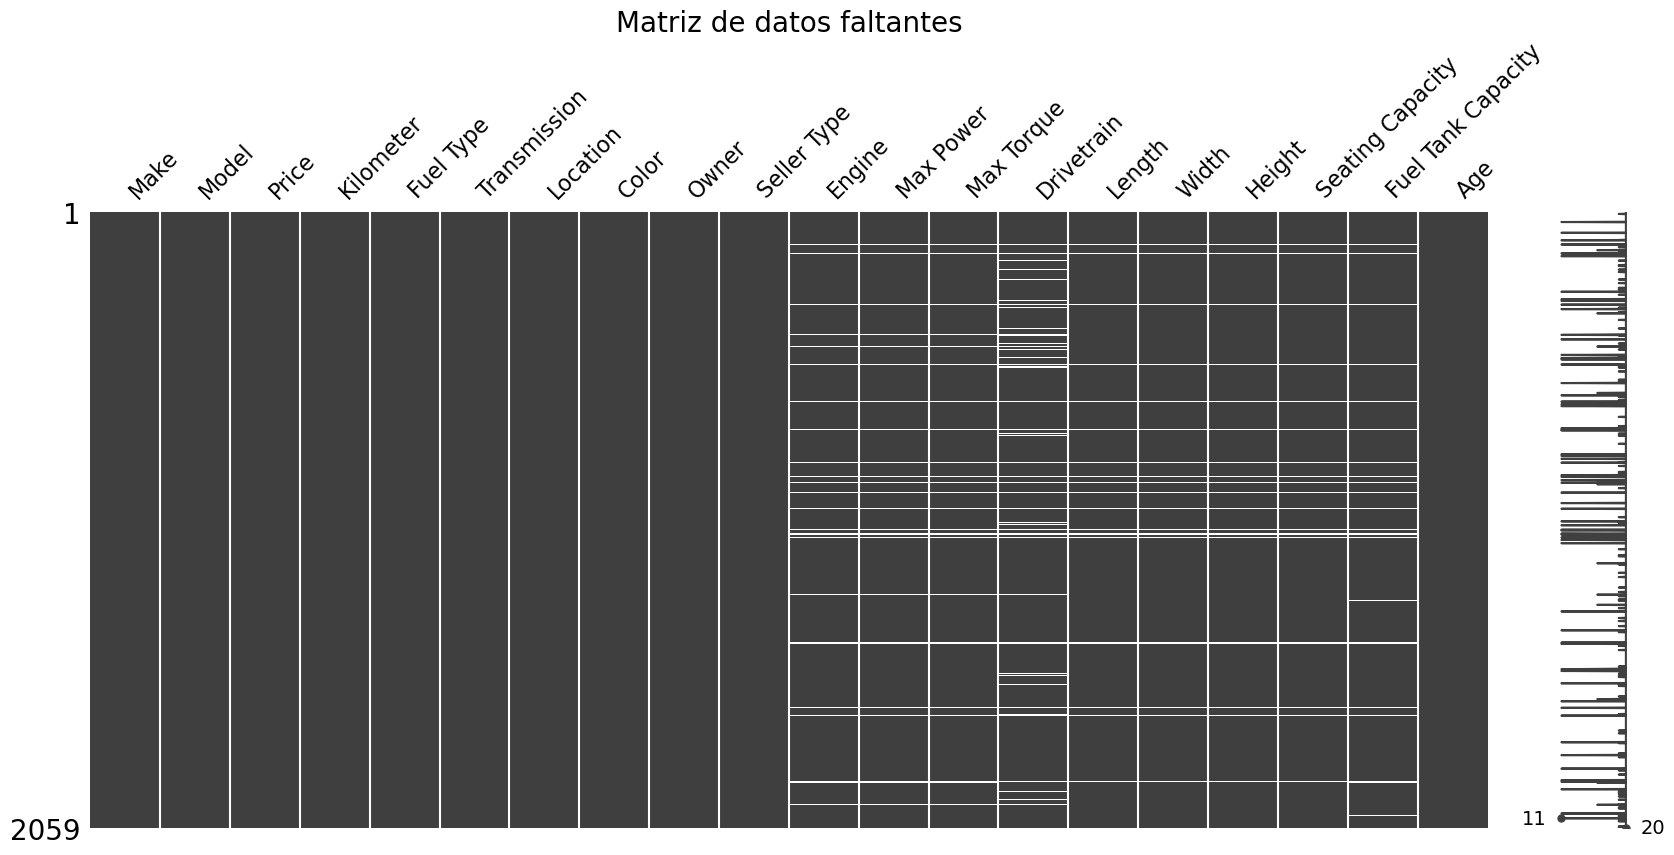

In [19]:
msno.matrix(df_base, figsize=(20,8))
plt.title("Matriz de datos faltantes", fontsize=20)
plt.show()

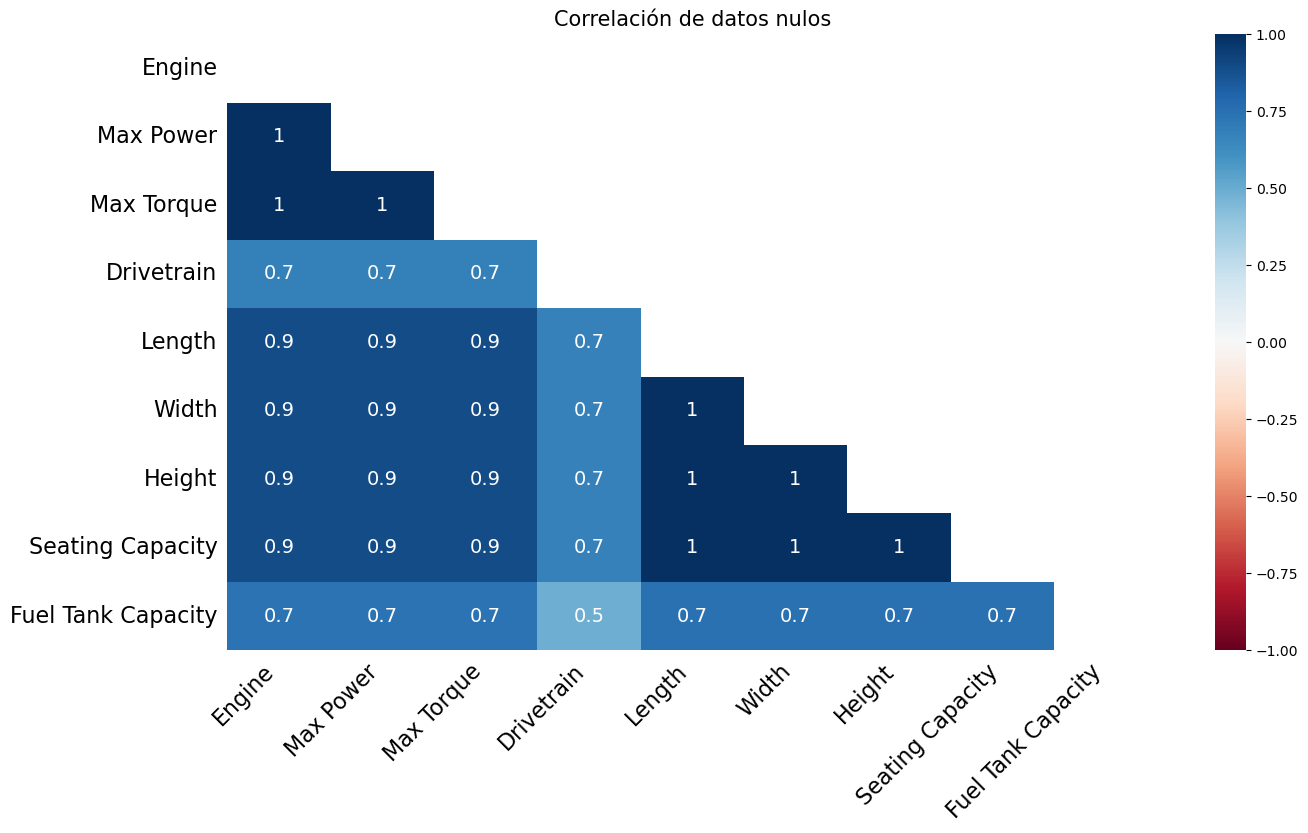

In [20]:
msno.heatmap(df_base, figsize=(15,8))
plt.title("Correlación de datos nulos", fontsize=15)
plt.show()

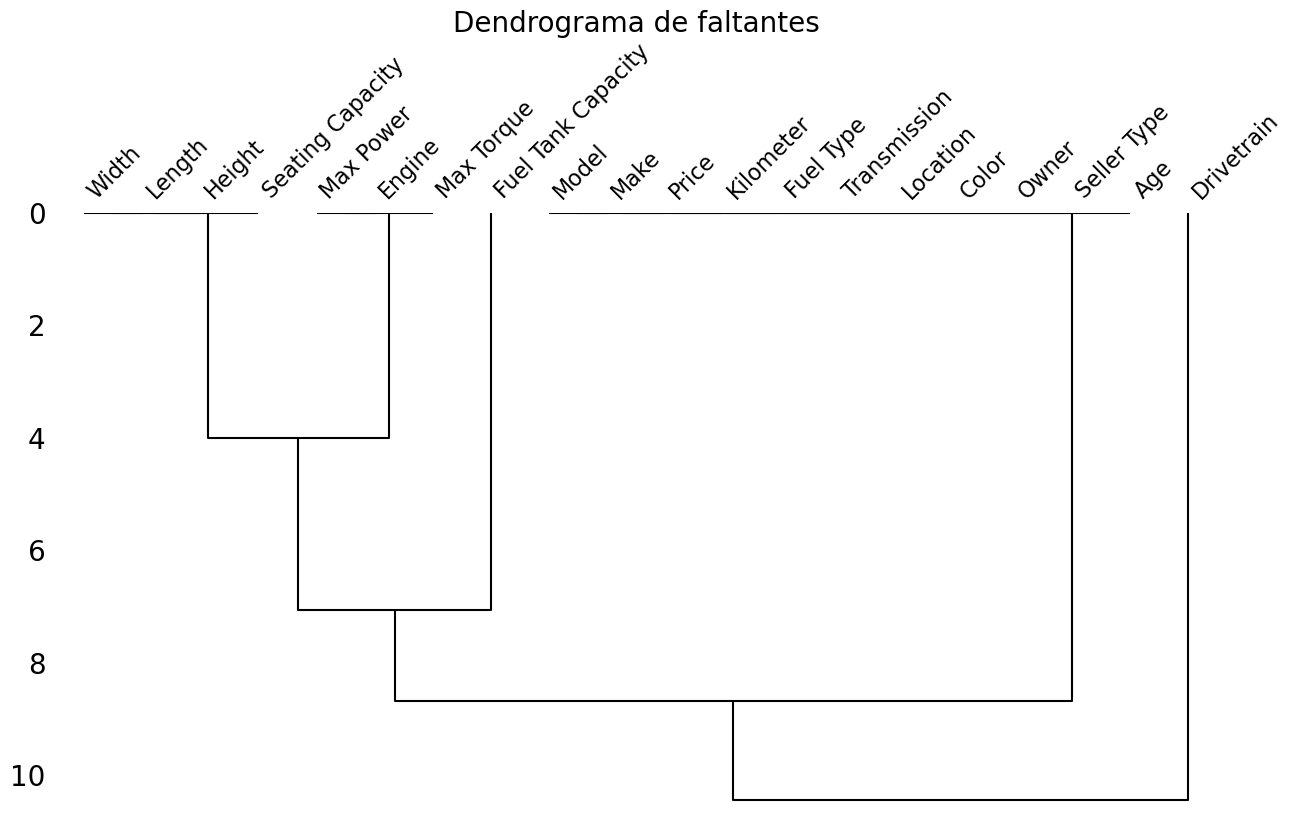

In [21]:

msno.dendrogram(df_base, figsize=(15,8))
plt.title('Dendrograma de faltantes', fontsize=20)
plt.show()

### Análisis de outliers

Se identifican observaciones en colas de distribuciones o fuera de rangos plausibles que puedan distorsionar estimaciones; las decisiones de recorte o transformación se aplican después sobre el conjunto de entrenamiento.

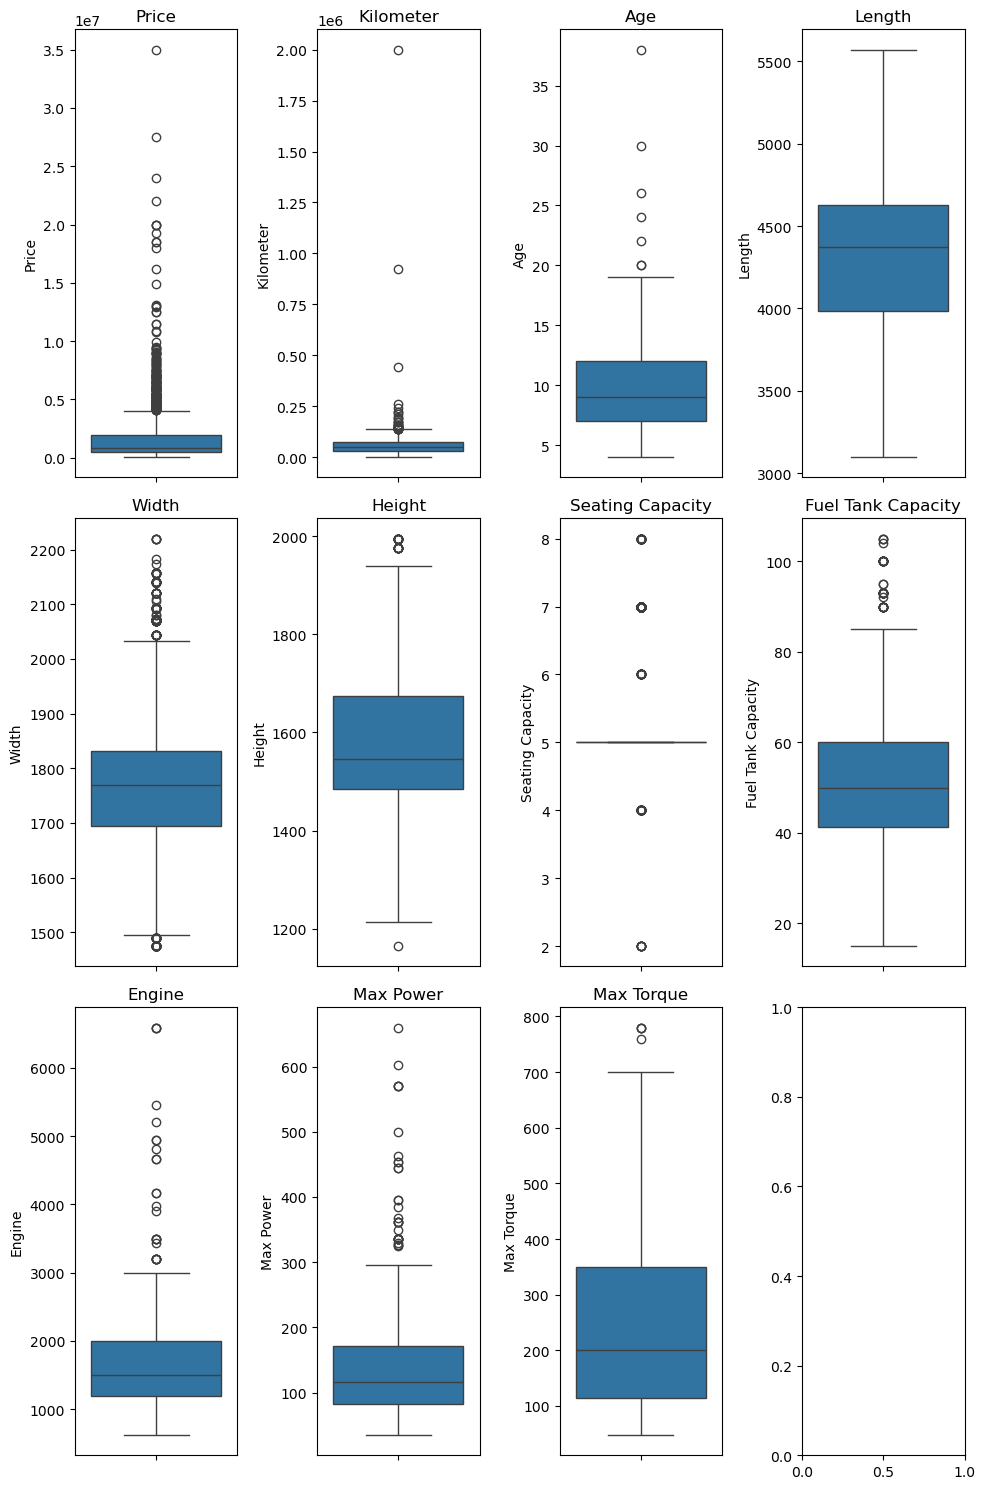

In [22]:
# Visualización de outliers con boxplots
fig, axes = plt.subplots(3, 4, figsize=(10, 15))

# Boxplot para 'Price'
sns.boxplot(y=df_base['Price'], ax=axes[0,0])
axes[0,0].set_title('Price')

# Boxplot para 'Kilometer'
sns.boxplot(y=df_base['Kilometer'], ax=axes[0,1])
axes[0,1].set_title('Kilometer')

# Boxplot para 'Age'
sns.boxplot(y=df_base['Age'], ax=axes[0,2])
axes[0,2].set_title('Age')

# Boxplot para 'Length'
sns.boxplot(y=df_base['Length'], ax=axes[0,3])
axes[0,3].set_title('Length')

# Boxplot para 'Width'
sns.boxplot(y=df_base['Width'], ax=axes[1,0])
axes[1,0].set_title('Width')

# Boxplot para 'Height'
sns.boxplot(y=df_base['Height'], ax=axes[1,1])
axes[1,1].set_title('Height')

# Boxplot para 'Seating Capacity'
sns.boxplot(y=df_base['Seating Capacity'], ax=axes[1,2])
axes[1,2].set_title('Seating Capacity')

# Boxplot para 'Fuel Tank Capacity'
sns.boxplot(y=df_base['Fuel Tank Capacity'], ax=axes[1,3])
axes[1,3].set_title('Fuel Tank Capacity')

# Boxplot para 'Engine'
sns.boxplot(y=df_base['Engine'], ax=axes[2,0])
axes[2,0].set_title('Engine')

# Boxplot para 'Max Power'
sns.boxplot(y=df_base['Max Power'], ax=axes[2,1])
axes[2,1].set_title('Max Power')

# Boxplot para 'Max Torque'
sns.boxplot(y=df_base['Max Torque'], ax=axes[2,2])
axes[2,2].set_title('Max Torque')

plt.tight_layout()
plt.show()

In [23]:
df_base.describe()

,Price,Kilometer,Engine,Max Power,Max Torque,Length,Width,Height,Seating Capacity,Fuel Tank Capacity,Age
count,2.059000e+03,2.059000e+03,1979.000000,1979.000000,1979.000000,1995.000000,1995.000000,1995.000000,1995.000000,1946.000000,2059.000000
mean,1.702992e+06,5.422471e+04,1692.575543,129.611774,245.851019,4280.860652,1767.991980,1591.735338,5.306266,52.002210,9.574551
std,2.419881e+06,5.736172e+04,643.736294,65.073797,140.465731,442.458507,135.265825,136.073956,0.822170,15.110198,3.363564
min,4.900000e+04,0.000000e+00,624.000000,35.000000,48.000000,3099.000000,1475.000000,1165.000000,2.000000,15.000000,4.000000
25%,4.849990e+05,2.900000e+04,1197.000000,83.000000,115.000000,3985.000000,1695.000000,1485.000000,5.000000,41.250000,7.000000
50%,8.250000e+05,5.000000e+04,1498.000000,116.000000,200.000000,4370.000000,1770.000000,1545.000000,5.000000,50.000000,9.000000
75%,1.925000e+06,7.200000e+04,1995.000000,171.000000,350.000000,4629.000000,1831.500000,1675.000000,5.000000,60.000000,12.000000
max,3.500000e+07,2.000000e+06,6592.000000,660.000000,780.000000,5569.000000,2220.000000,1995.000000,8.000000,105.000000,38.000000


#### `Fuel Type`

## Split del dataset

Se separa el conjunto en entrenamiento y prueba (80% / 20%) **antes** de imputaciones, codificaciones y escalados que usan estadísticos calculados sobre los datos, para reducir fugas de información entre particiones.

In [24]:
from sklearn.model_selection import train_test_split

df, test_df = train_test_split(df_base, test_size=0.2, random_state=42)

print(df.shape, test_df.shape)

(1647, 20) (412, 20)


## Preprocesamiento de datos

Se limpian filas y valores atípicos según lo definido en el EDA, se codifican variables categóricas, se escalan numéricas cuando el algoritmo lo requiere y, al final, se aplica reducción de dimensionalidad por PCA sobre la matriz de características.

### Tratamiento de datos faltantes

Se eliminan o imputan ausencias según la importancia de la variable y el volumen de datos, priorizando no introducir ruido en atributos clave del vehículo.

In [25]:
print(f"Valores faltantes: {df.isna().sum()}")  # Calcular valores faltantes

Valores faltantes: Make                    0
Model                   0
Price                   0
Kilometer               0
Fuel Type               0
Transmission            0
Location                0
Color                   0
Owner                   0
Seller Type             0
Engine                 65
Max Power              65
Max Torque             65
Drivetrain            111
Length                 52
Width                  52
Height                 52
Seating Capacity       52
Fuel Tank Capacity     90
Age                     0
dtype: int64


Eliminamos las filas donde `Length`, `Width`, `Height`, `Seating Capacity` son nulos. También eliminamos las filas donde `Engine`, `Max Power`, `Max Torque` son nulos. Esto es porque son variables clave e imputarlas generaría ruido. Además, el dataset es suficientemente grande.

Se imputan los faltantes de `Fuel Tank Capacity` con la mediana  y `Drivetrain` con la moda.

In [26]:
# Eliminar filas
df.dropna(subset=['Length', 'Width', 'Height', 'Seating Capacity', 'Engine', 'Max Power', 'Max Torque'], inplace=True)

# Imputar 'Fuel Tank Capacity' con la mediana
median = df['Fuel Tank Capacity'].median()
print('La mediana de Fuel Tank Capacity es:', median)
df.fillna({'Fuel Tank Capacity':median}, inplace=True)

# Imputar 'Drivetrain' con la moda
mode = df['Drivetrain'].mode()[0]
print('La moda de Drivetrain es:', mode)
df.fillna({'Drivetrain':mode}, inplace=True)

print(f"\nValores faltantes:\n{df.isna().sum()}")  # Calcular valores faltantes

La mediana de Fuel Tank Capacity es: 50.0
La moda de Drivetrain es: FWD

Valores faltantes:
Make                  0
Model                 0
Price                 0
Kilometer             0
Fuel Type             0
Transmission          0
Location              0
Color                 0
Owner                 0
Seller Type           0
Engine                0
Max Power             0
Max Torque            0
Drivetrain            0
Length                0
Width                 0
Height                0
Seating Capacity      0
Fuel Tank Capacity    0
Age                   0
dtype: int64


### Tratamiento de outliers

Sobre el conjunto de entrenamiento se aplican transformaciones y reglas de recorte coherentes con el EDA. Se utilizan las siguientes técnicas para cada variable numérica, en base al análisis previo:
- `Price`: transformación logarítmica
- `Kilometer`: eliminación por IQR
- `Age`: no se modifica
- `Length`, `Width`, `Height`: no se modifican
- `Seating Capacity`: no se modifica
- `Fuel Tank Capacity`: no se modifica
- `Engine`: transformación logarítmica
- `Max Power`: transformación logarítmica
- `Max Torque`: no se modifica

Para las variables categoricas se hizo un tratamiento sobre los valores con menor frecuencia.

In [27]:
# Transformación logarítmica
df['Price'] = np.log1p(df['Price'])
df['Engine'] = np.log1p(df['Engine'])
df['Max Power'] = np.log1p(df['Max Power'])

In [28]:
# Eliminación por IQR para 'Kilometer'
Q1 = df['Kilometer'].quantile(0.25)
Q3 = df['Kilometer'].quantile(0.75)
IQR = Q3 - Q1
df = df[df['Kilometer'] >= Q1 - 1.5 * IQR]
df = df[df['Kilometer'] <= Q3 + 1.5 * IQR]

print(f"Outliers\nKilometer: <{Q1 - 1.5 * IQR:.02f} o >{Q3 + 1.5 * IQR:.02f}")

Outliers
Kilometer: <-36343.12 o >137005.88


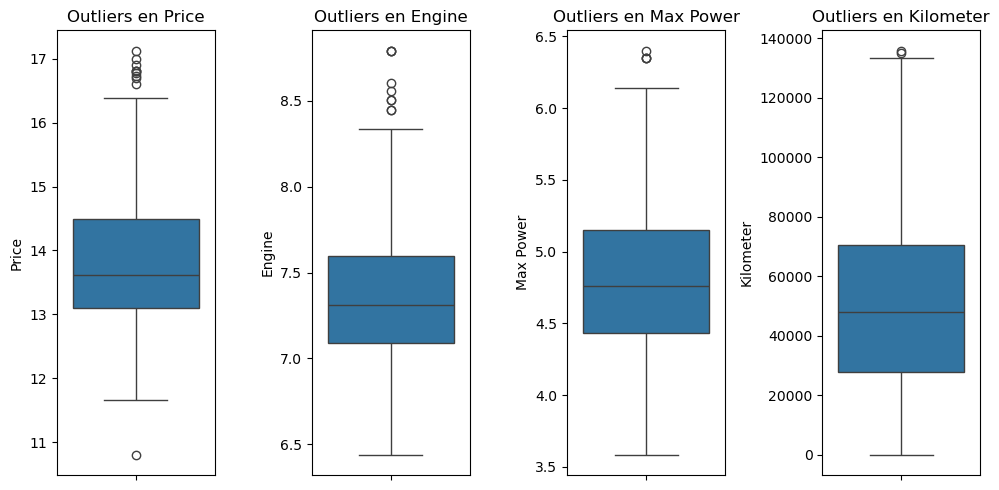

In [29]:
fig, axes = plt.subplots(1, 4, figsize=(10, 5))

# Boxplot para 'Price'
sns.boxplot(y=df['Price'], ax=axes[0])
axes[0].set_title('Outliers en Price')

# Boxplot para 'Engine'
sns.boxplot(y=df['Engine'], ax=axes[1])
axes[1].set_title('Outliers en Engine')

# Boxplot para 'Max Power'
sns.boxplot(y=df['Max Power'], ax=axes[2])
axes[2].set_title('Outliers en Max Power')

# Boxplot para 'Kilometer'
sns.boxplot(y=df['Kilometer'], ax=axes[3])
axes[3].set_title('Outliers en Kilometer')

plt.tight_layout()
plt.show()

#### `Fuel Type`

Se agrupan aquellas categorías de `Fuel Type` con frecuencia menor a 1% bajo `"Other"` para evitar sobreajuste y simplificar los modelos.

In [30]:
# Agrupación de categorías de "Fuel Type" con frecuencia menor a 1% bajo "Other"
freq = df["Fuel Type"].value_counts(normalize=True)
rare = freq[freq < 0.01].index

df["Fuel Type"] = df["Fuel Type"].cat.add_categories("Other")
df["Fuel Type"] = df["Fuel Type"].replace(rare, "Other")
df["Fuel Type"] = df["Fuel Type"].cat.remove_unused_categories()

# Arreglo de categorías "Fuel Type" - No Other
arr_FuelType = df["Fuel Type"].value_counts().drop("Other").index.tolist()

# Conteo de "Fuel Type"
df['Fuel Type'].value_counts()

C:\Users\mcnal\AppData\Local\Temp\ipykernel_10416\276981457.py:6: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df["Fuel Type"] = df["Fuel Type"].replace(rare, "Other")


Fuel Type
Diesel    783
Petrol    722
CNG        38
Other       8
Name: count, dtype: int64

#### `Color`

In [31]:
# Conteo de "Color"
df['Color'].value_counts()

Color
White     599
Silver    211
Grey      167
Blue      137
Black     131
Red       118
Brown      67
Maroon     30
Gold       22
Bronze     21
Green      14
Orange     10
Others     10
Beige       5
Yellow      5
Purple      3
Pink        1
Name: count, dtype: int64

Se agrupan aquellas categorías de `Color` con frecuencia menor a 1% bajo `"Other"` debido al gran número de categorías con baja frecuencia, para evitar sobreajuste y simplificar los modelos.

In [32]:
# Agrupación de categorías de "Color" con frecuencia menor a 1% bajo "Other"
freq = df["Color"].value_counts(normalize=True)
rare = freq[freq < 0.01].index

df["Color"] = df["Color"].cat.add_categories("Other")
df["Color"] = df["Color"].replace(rare, "Other")
df["Color"] = df["Color"].cat.remove_unused_categories()

# Arreglo de categorías "Color" - No Other
arr_Color = df["Color"].value_counts().drop("Other").index.tolist()

# Conteo de "Color"
df['Color'].value_counts()

C:\Users\mcnal\AppData\Local\Temp\ipykernel_10416\22602398.py:6: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df["Color"] = df["Color"].replace(rare, "Other")


Color
White     599
Silver    211
Grey      167
Blue      137
Black     131
Red       118
Brown      67
Other      48
Maroon     30
Gold       22
Bronze     21
Name: count, dtype: int64

#### `Owner`

In [33]:
# Conteo de "Owner"
df['Owner'].value_counts()

Owner
First               1246
Second               256
Third                 30
UnRegistered Car      15
Fourth                 3
4 or More              1
Name: count, dtype: int64

Se combinan las categorías `"Fourth"` y `"4 or More"` de `Owner`, ya que parecerían pertenecer a la misma clase y su frecuencia es baja.

In [34]:
# Combinación de "Fourth" y "4 or More" para Owner
df['Owner'] = df['Owner'].replace('Fourth', '4 or More')
df["Owner"] = df["Owner"].cat.remove_unused_categories()

# Conteo de "Owner"
df['Owner'].value_counts()

C:\Users\mcnal\AppData\Local\Temp\ipykernel_10416\4108362436.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['Owner'] = df['Owner'].replace('Fourth', '4 or More')


Owner
First               1246
Second               256
Third                 30
UnRegistered Car      15
4 or More              4
Name: count, dtype: int64

### Codificación

Cada variable categórica se representa numéricamente con el esquema que mejor equilibra interpretabilidad, cardinalidad y riesgo de sobreajuste. Se utilizan las siguientes técnicas para cada variable categórica:
- `Make`: frequency encoding
- `Fuel Type`: one-hot encoding
- `Transmission`: one-hot encoding
- `Location`: frequency encoding
- `Color`: target encoding
- `Owner`: ordinal encoding
- `Seller Type`: one-hot encoding
- `Drivetrain`: one-hot encoding

#### Frequency encoding

In [35]:
# Frequency Encoding

# Make
make_freq = df["Make"].value_counts(normalize=True)
df["Make_freq"] = df["Make"].map(make_freq)

# Location
location_freq = df["Location"].value_counts(normalize=True)
df["Location_freq"] = df["Location"].map(location_freq)

# Drop originales
df.drop(columns=["Make", "Location"], inplace=True)

#### One-hot encoding

In [36]:
# One-Hot Encoding
columns = ['Fuel Type', 'Transmission', 'Seller Type', 'Drivetrain']
df = pd.get_dummies(df, columns=columns, drop_first=True)

#### Target encoding

In [37]:
# Target Encoding
price_mean_by_color = df.groupby("Color")["Price"].mean()

df["Color_target"] = df["Color"].map(price_mean_by_color)
df.drop(columns=["Color"], inplace=True)

C:\Users\mcnal\AppData\Local\Temp\ipykernel_10416\1732462077.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_mean_by_color = df.groupby("Color")["Price"].mean()


#### Ordinal encoding

In [38]:
# Valores distintos de Owner
df['Owner'].unique()

['First', 'Second', 'Third', 'UnRegistered Car', '4 or More']
Categories (5, object): ['4 or More', 'First', 'Second', 'Third', 'UnRegistered Car']

In [39]:
# Cantidad de filas con Owner = "UnRegistered Car"
df[df['Owner'] == "UnRegistered Car"].shape[0]


15

Para aprovechar la naturaleza ordinal de la variable `Owner`, se eliminan las 15 filas con `UnRegistered Car` al considerarse "outliers".

In [40]:
# Eliminar filas con Owner = "UnRegistered Car"
df = df[df['Owner'] != "UnRegistered Car"]
df['Owner'].unique()

['First', 'Second', 'Third', '4 or More']
Categories (5, object): ['4 or More', 'First', 'Second', 'Third', 'UnRegistered Car']

In [41]:
from sklearn.preprocessing import OrdinalEncoder

# Definir el orden
orden = [["First", "Second", "Third", "Fourth", "4 or More"]]

oe = OrdinalEncoder(categories=orden)

df["Owner_encoded"] = oe.fit_transform(df[["Owner"]])

# Drop originales
df.drop(columns=["Owner"], inplace=True)

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1536 entries, 1133 to 860
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   Model                   1536 non-null   object  
 1   Price                   1536 non-null   float64 
 2   Kilometer               1536 non-null   int64   
 3   Engine                  1536 non-null   float64 
 4   Max Power               1536 non-null   float64 
 5   Max Torque              1536 non-null   float64 
 6   Length                  1536 non-null   float64 
 7   Width                   1536 non-null   float64 
 8   Height                  1536 non-null   float64 
 9   Seating Capacity        1536 non-null   float64 
 10  Fuel Tank Capacity      1536 non-null   float64 
 11  Age                     1536 non-null   int64   
 12  Make_freq               1536 non-null   float64 
 13  Location_freq           1536 non-null   float64 
 14  Fuel Type_Diesel        153

In [43]:
df.head()

,Model,Price,Kilometer,Engine,Max Power,Max Torque,Length,Width,Height,Seating Capacity,...,Fuel Type_Diesel,Fuel Type_Petrol,Fuel Type_Other,Transmission_Manual,Seller Type_Corporate,Seller Type_Individual,Drivetrain_FWD,Drivetrain_RWD,Color_target,Owner_encoded
1133,X1 sDrive20d xLine,14.603514,77000,7.598900,5.220356,350.0,4454.0,2044.0,1545.0,5.0,...,True,False,False,False,False,True,False,True,14.467237,0.0
1823,XUV500 W4 1.99,13.592368,112000,7.599902,4.934474,320.0,4585.0,1890.0,1785.0,7.0,...,True,False,False,True,False,True,True,False,13.376572,0.0
1370,GLS 400d 4MATIC,16.372738,3000,7.981392,5.789960,700.0,5207.0,2157.0,1823.0,7.0,...,True,False,False,False,False,True,False,False,13.882948,0.0
67,Fortuner 2.8 4x2 AT [2016-2020],15.067988,73000,7.921536,5.164786,450.0,4795.0,1855.0,1835.0,7.0,...,True,False,False,False,False,True,False,True,13.882948,0.0
1009,Vitara Brezza ZDi+ Dual Tone [2017-2018],13.369225,52000,7.130099,4.499810,200.0,3995.0,1790.0,1640.0,5.0,...,True,False,False,True,False,True,True,False,14.373091,1.0


### Estandarización

Se aplica estandarización (media cero, varianza unidad) a las variables numéricas con `StandardScaler`, de modo que magnitudes distintas no dominen el ajuste en modelos sensibles a la escala, como la regresión lineal regularizada o SVM.

In [44]:
# Top 10 valores de Model y su frecuencia
df['Model'].value_counts().head(10)

Model
X1 sDrive20d xLine                 14
Fortuner 2.8 4x2 AT [2016-2020]    12
Swift DZire VDI                    11
Swift VXi                          10
A6 35 TDI Matrix                   10
Swift DZire VXI                     9
Alto VXi                            8
Verna Fluidic 1.6 CRDi SX           8
Alto 800 Lxi                        8
i10 Magna 1.2 Kappa2                7
Name: count, dtype: int64

Se elimina la única columna de tipo `string` que queda, `Model`, debido a su alta cardinalidad y baja representatividad. Se cuenta con el atributo `Make` que sirve el mismo propósito de forma más general.

In [45]:
# Eliminar Model
df.drop(columns=["Model"], inplace=True)

In [46]:
# Convertir columnas booleanas a int
df = df.astype({col: int for col in df.select_dtypes(include="bool").columns})

In [47]:
from sklearn.preprocessing import StandardScaler

# Estandarización (Z-Score)
scaler = StandardScaler()
df = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
train_cols = df.columns.tolist()

### Reducción de dimensionalidad

Tras la correlación entre predictores, se sintetiza la información en componentes principales para obtener una representación más compacta antes del modelado.

#### Análisis de matrices de correlación

Se visualizan correlaciones lineales y monotónicas entre predictores y con el precio para decidir redundancias antes del PCA.

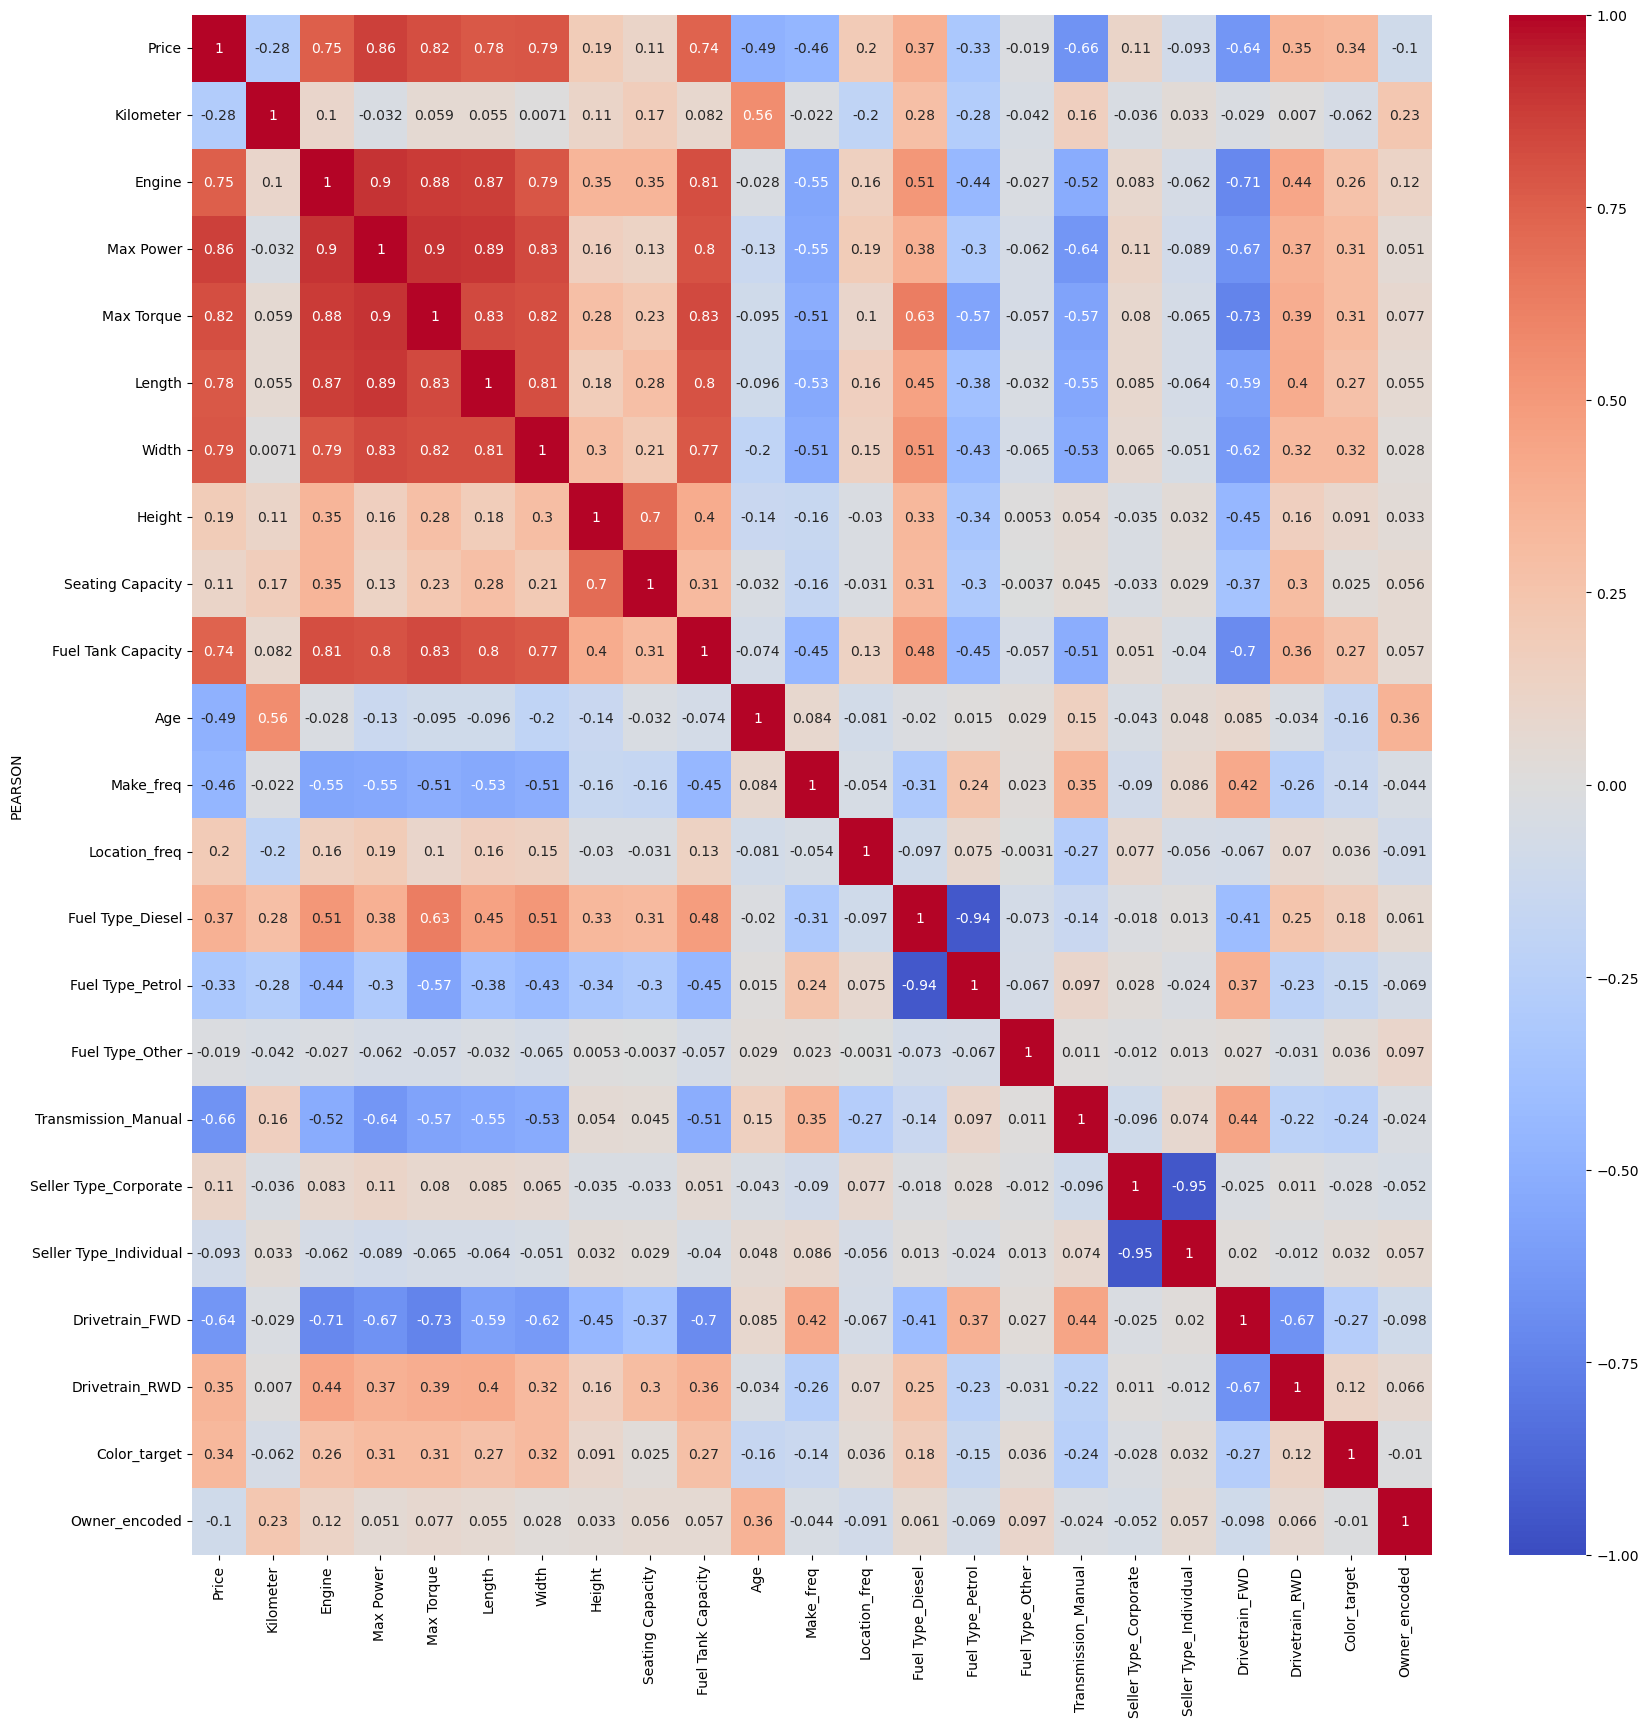

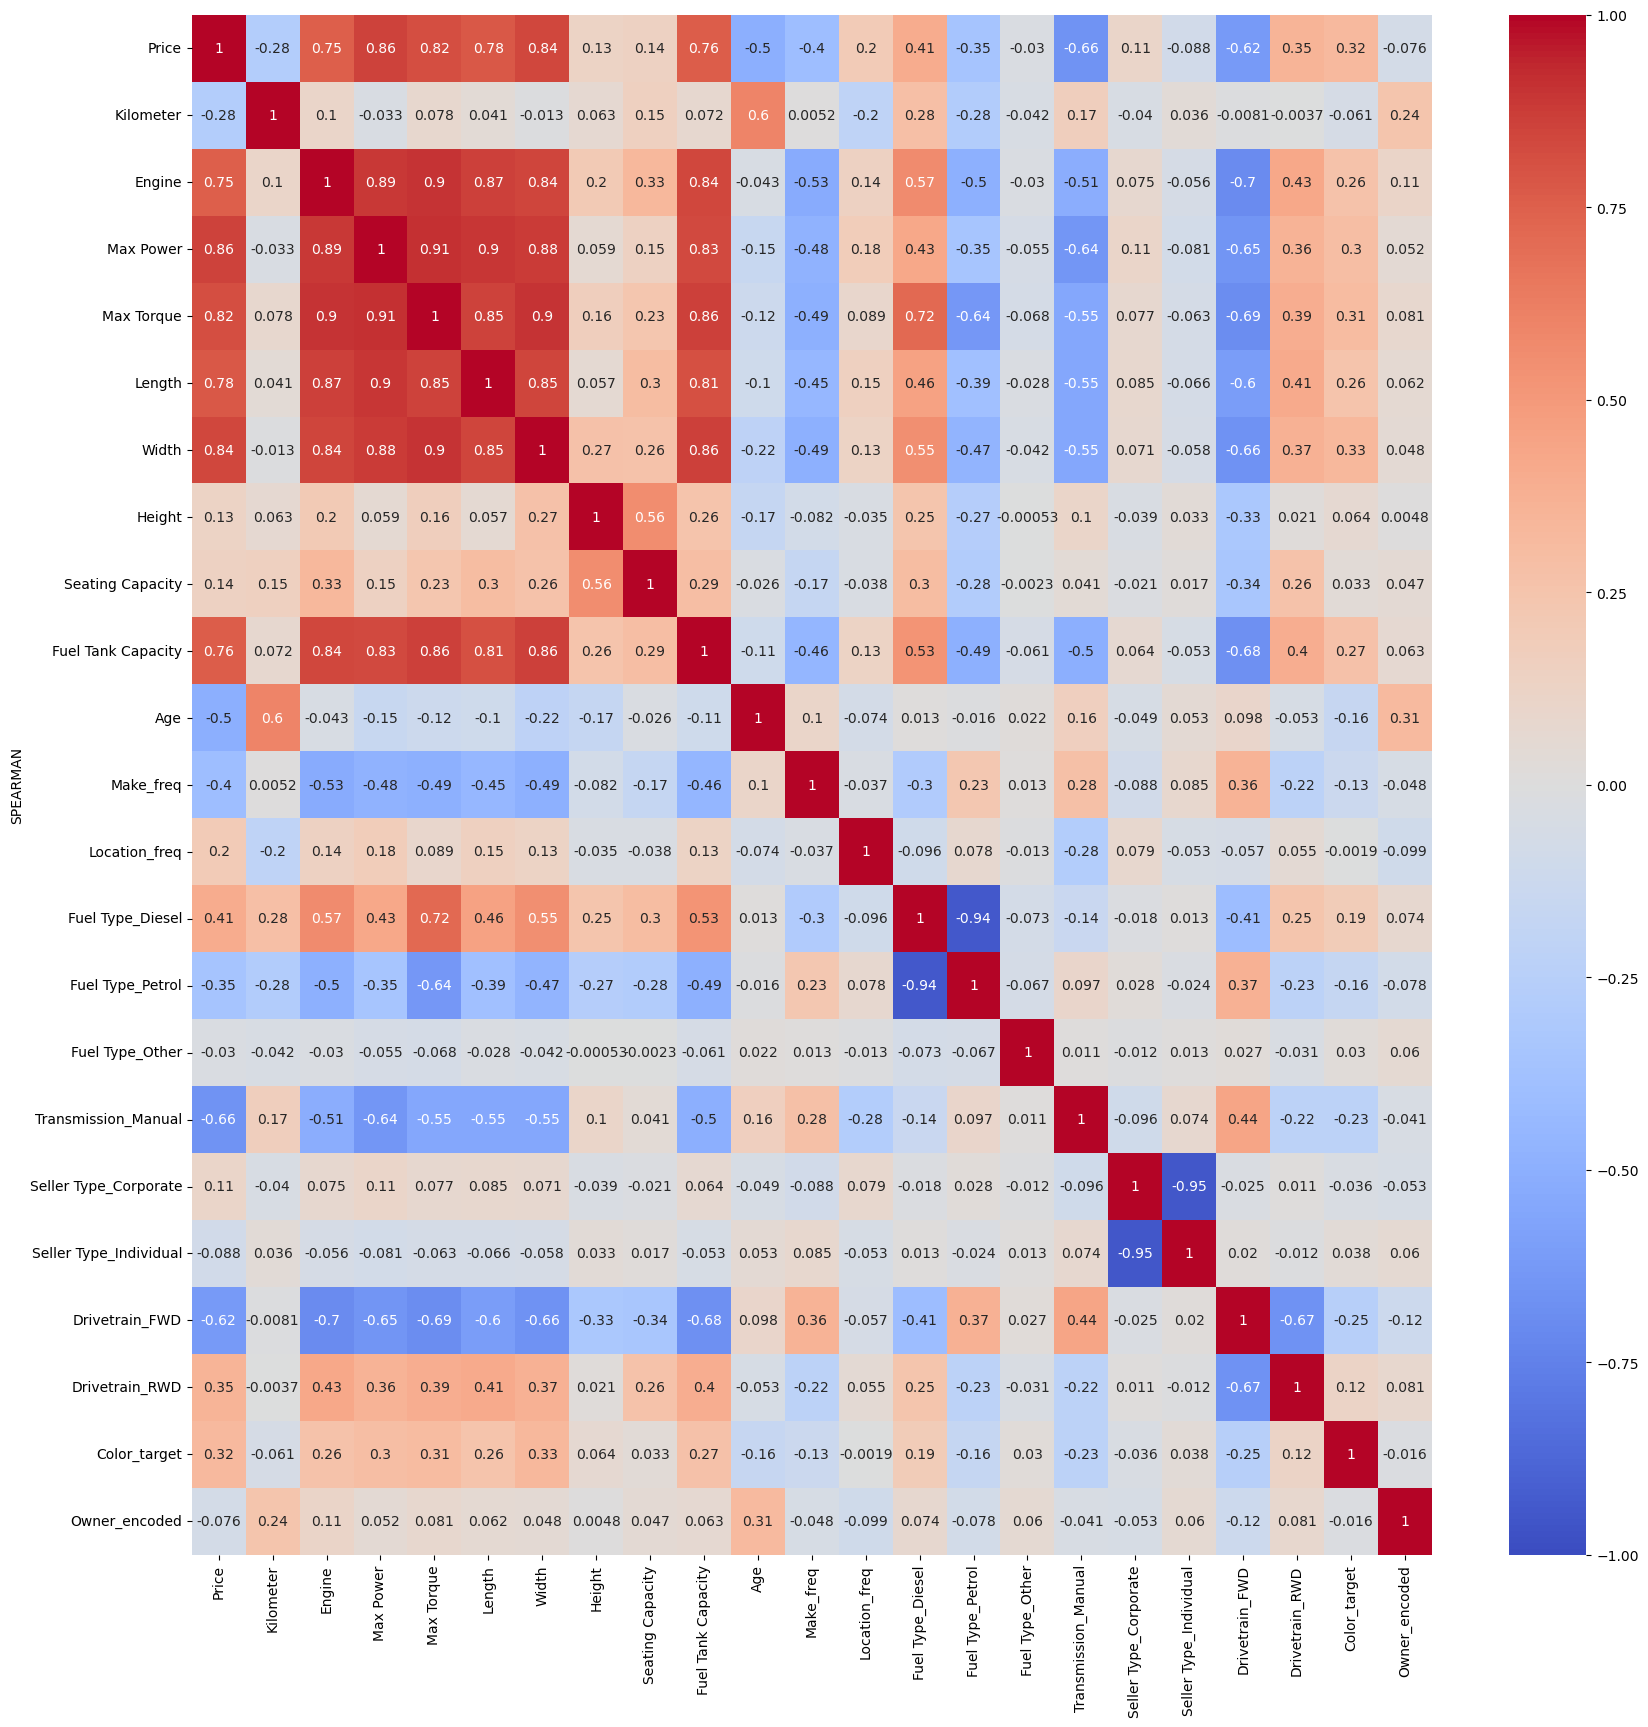

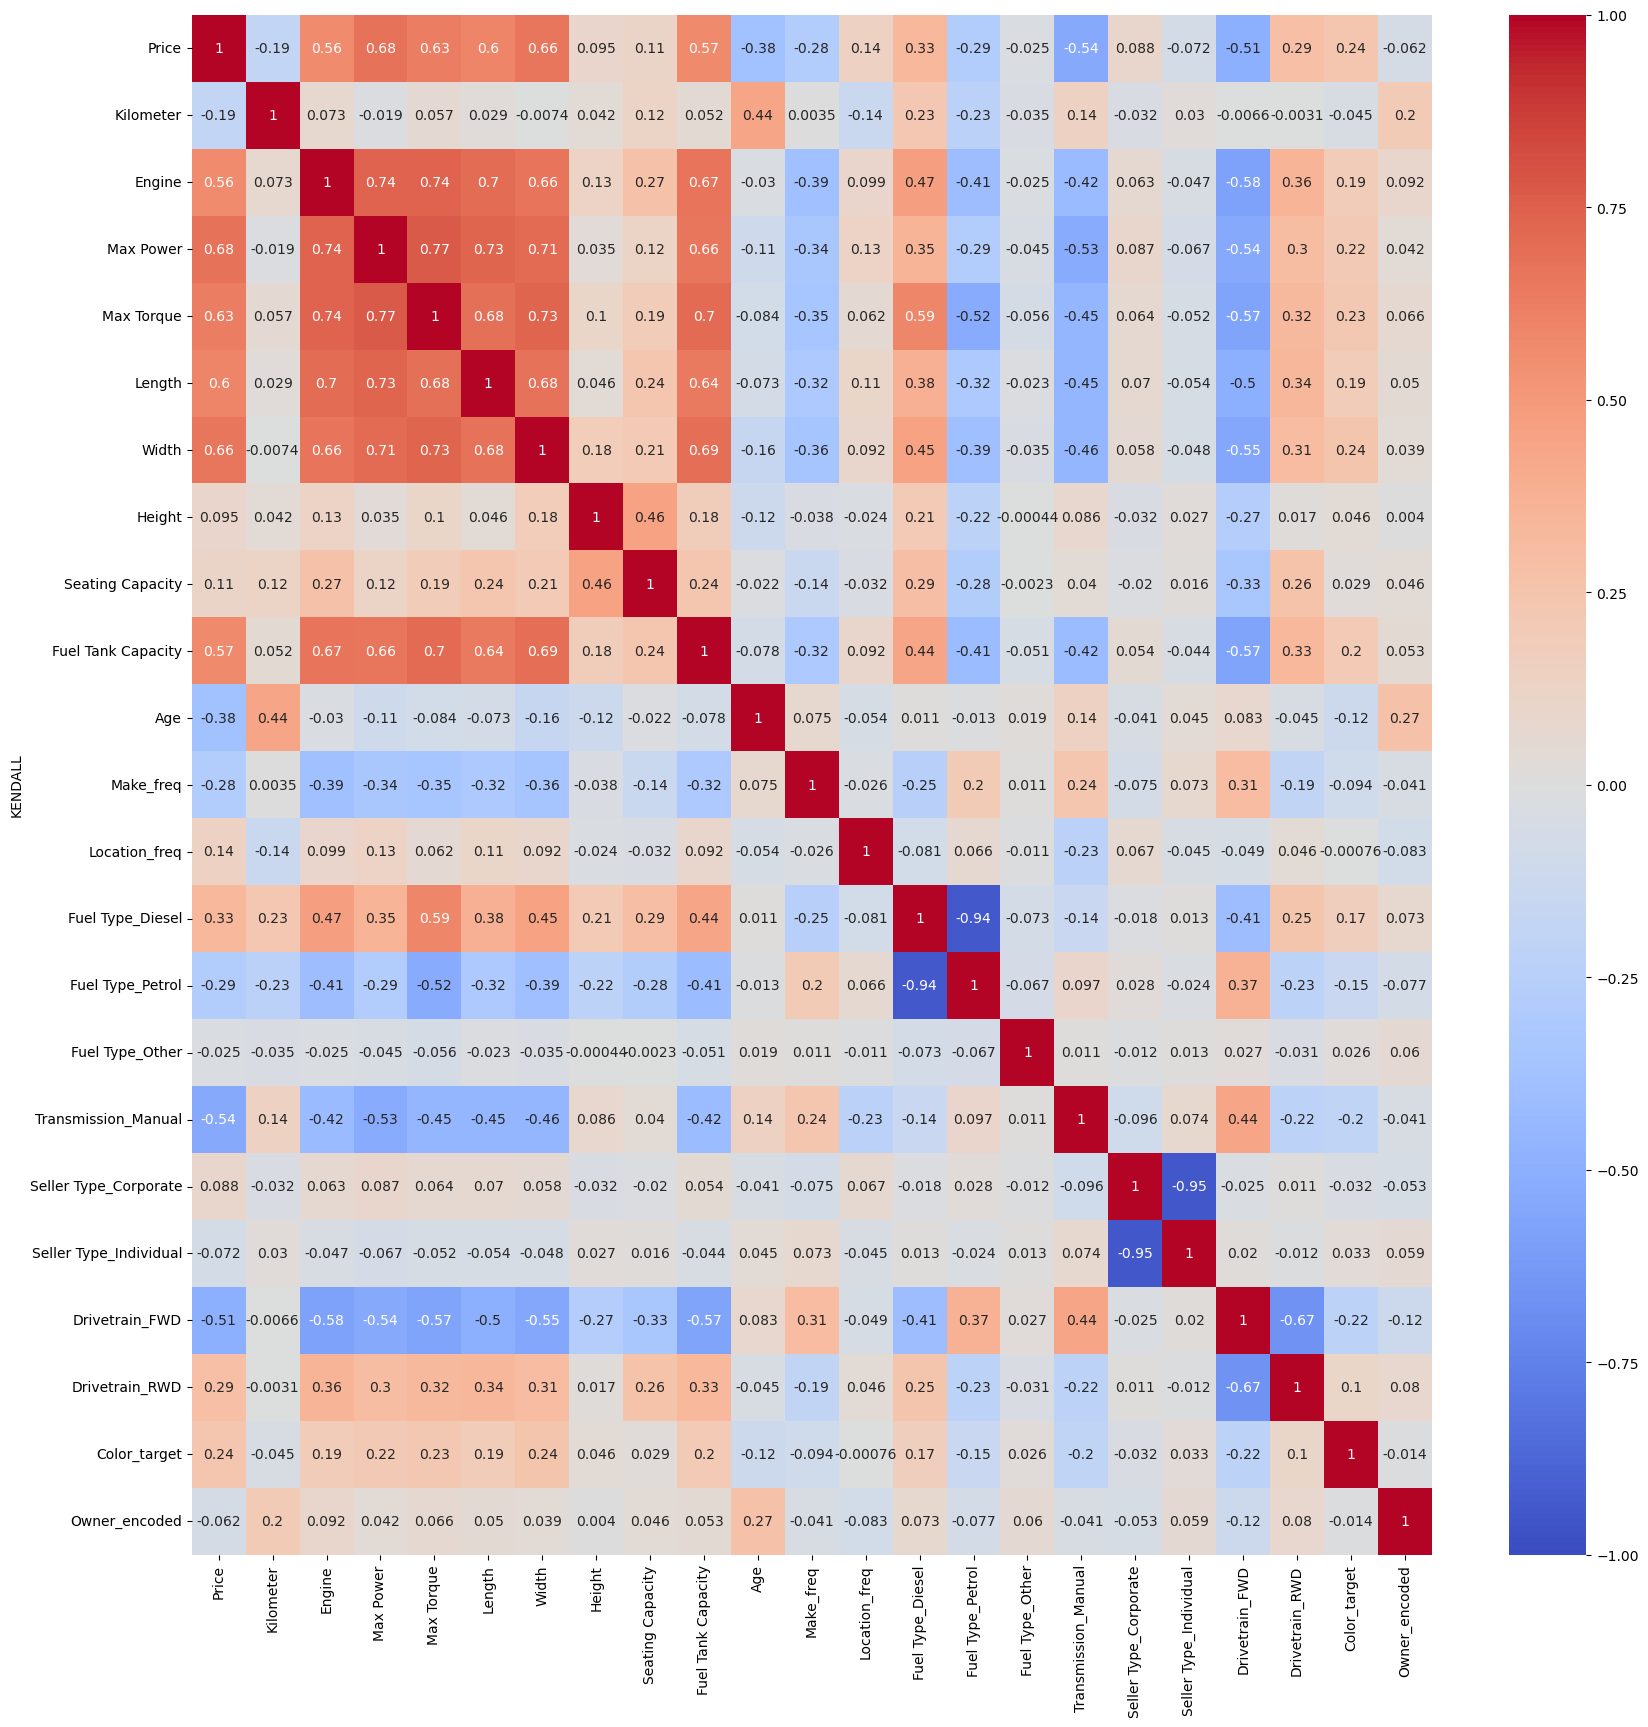

In [48]:
plt.figure(figsize=(20, 20))
sns.heatmap(
    df.corr(numeric_only=False),
    annot=True,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1)
plt.ylabel('PEARSON')
plt.show()

plt.figure(figsize=(20, 20))
sns.heatmap(
    df.corr(method='spearman', numeric_only=False),
    annot=True,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,)
plt.ylabel('SPEARMAN')
plt.show()

plt.figure(figsize=(20, 20))
sns.heatmap(
    df.corr(method='kendall', numeric_only=False),
    annot=True,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,)
plt.ylabel('KENDALL')

plt.show()

- Se descarta la columna `Fuel Type_Other` debido a su baja correlación con la variable objetivo `Price`.
- Se descartan las columnas `Engine`, `Max Torque`, `Length`, `Width` y `Fuel Tank Capacity` debido a su alta correlación con la variable `Max Power`.
- Se descarta la columna `Fuel Type_Diesel` debido a su alta correlación con la variable `Fuel Type_Petrol`.
- Se descarta la columna `Seller Type_Corporate` debido a su alta correlación con la variable `Seller Type_Individual`.

In [49]:
df.drop(columns=["Fuel Type_Other", "Engine", "Max Torque", "Length", "Width", "Fuel Tank Capacity", "Fuel Type_Diesel", "Seller Type_Corporate"], inplace=True)
df.head()

,Price,Kilometer,Max Power,Height,Seating Capacity,Age,Make_freq,Location_freq,Fuel Type_Petrol,Transmission_Manual,Seller Type_Individual,Drivetrain_FWD,Drivetrain_RWD,Color_target,Owner_encoded
0,0.815806,0.931484,1.024759,-0.333531,-0.364918,0.168043,-0.691837,-1.070817,-0.929558,-1.107288,0.181528,-1.541371,2.301105,1.966224,-0.441446
1,-0.220541,2.176958,0.381760,1.444219,2.148597,-0.142190,-0.708657,-1.121652,-0.929558,0.903107,0.181528,0.648773,-0.434574,-1.336504,-0.441446
2,2.629126,-1.701804,2.305902,1.725696,2.148597,-1.383123,-0.321803,1.267591,-0.929558,-1.107288,0.181528,-1.541371,-0.434574,0.196895,-0.441446
3,1.291857,0.789144,0.899773,1.814584,2.148597,-0.762657,-0.599329,1.491264,-0.929558,-1.107288,0.181528,-1.541371,2.301105,0.196895,-0.441446
4,-0.449246,0.041860,-0.595879,0.370162,-0.364918,0.168043,1.376989,1.267591,-0.929558,0.903107,0.181528,0.648773,-0.434574,1.681133,1.600905


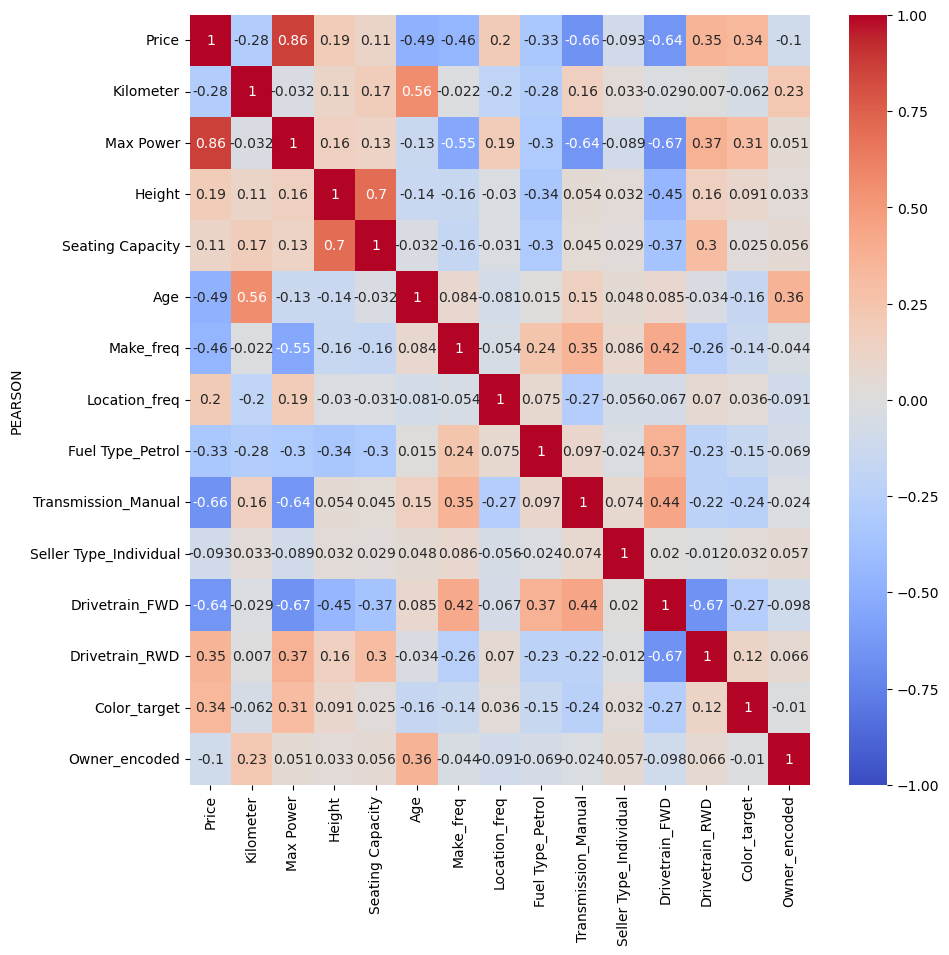

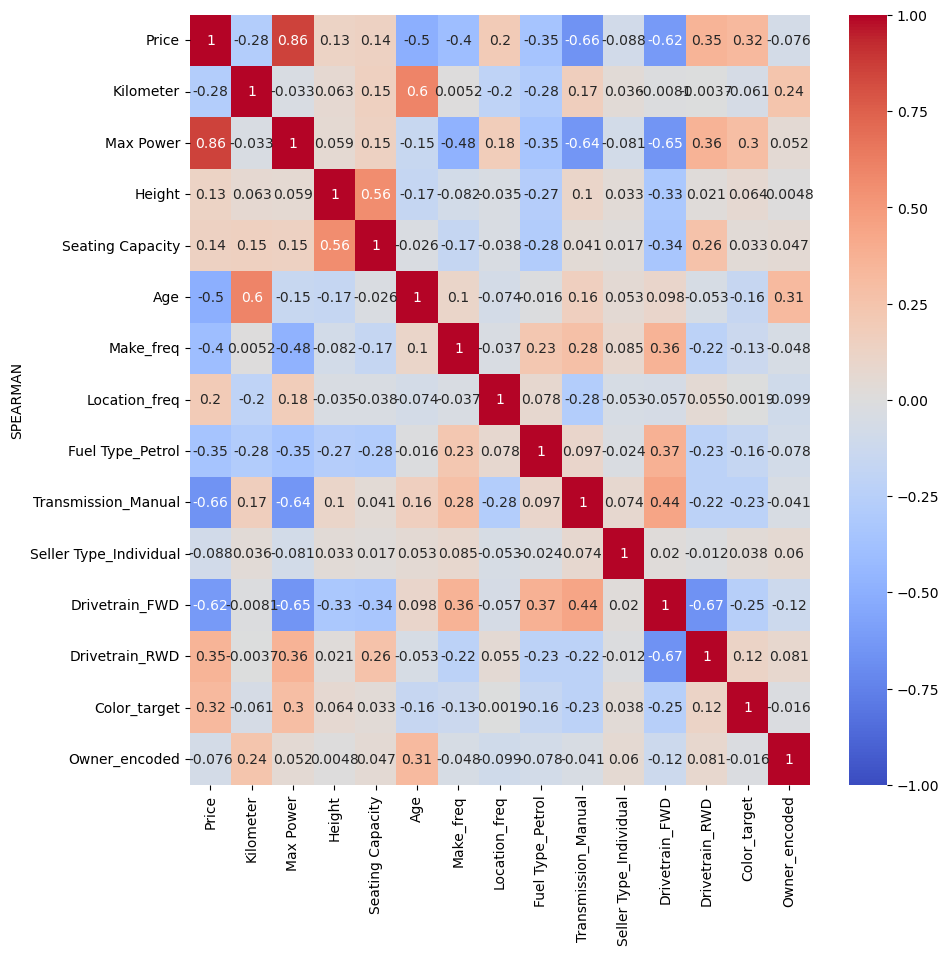

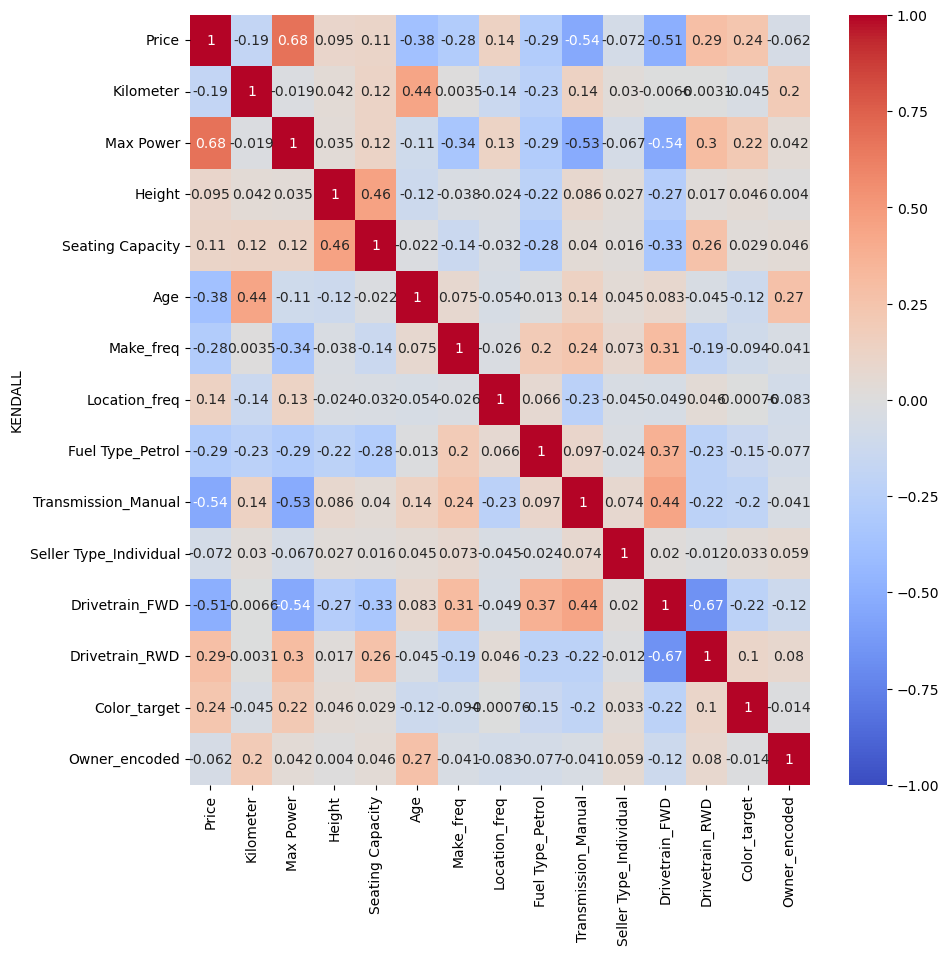

In [50]:
plt.figure(figsize=(10, 10))
sns.heatmap(
    df.corr(numeric_only=False),
    annot=True,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1)
plt.ylabel('PEARSON')
plt.show()

plt.figure(figsize=(10, 10))
sns.heatmap(
    df.corr(method='spearman', numeric_only=False),
    annot=True,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,)
plt.ylabel('SPEARMAN')
plt.show()

plt.figure(figsize=(10, 10))
sns.heatmap(
    df.corr(method='kendall', numeric_only=False),
    annot=True,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,)
plt.ylabel('KENDALL')

plt.show()

#### Análisis de componentes principales (PCA)

Se proyectan las características en ejes ortogonales que concentran la varianza y se elige el número de componentes según la varianza acumulada explicada.

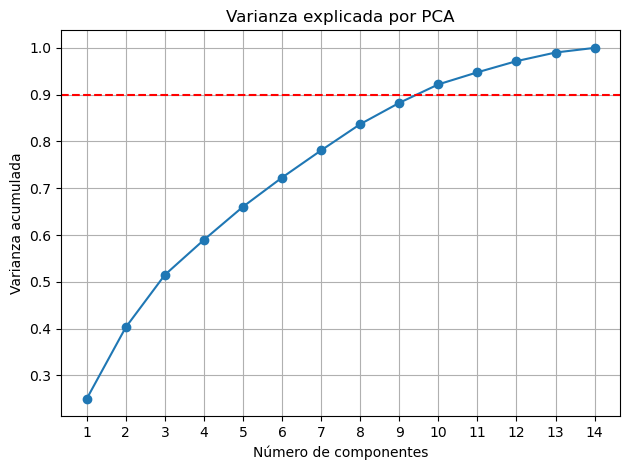

In [51]:
from sklearn.decomposition import PCA

X = df.drop(columns=["Price"])
y = df["Price"]

pca = PCA().fit(X)

# varianza explicada por cada componente
explained_var = pca.explained_variance_ratio_

# varianza acumulada
cumulative_var = np.cumsum(explained_var)

n_components = len(explained_var)
componentes = np.arange(1, n_components + 1)

plt.figure()
plt.plot(componentes, cumulative_var, marker='o')
plt.xticks(componentes)
plt.xlabel('Número de componentes')
plt.ylabel('Varianza acumulada')
plt.title('Varianza explicada por PCA')
plt.grid(True)
plt.axhline(y=0.9, color='red', linestyle='--', label='90% de varianza')
plt.tight_layout()
plt.show()

Se seleccionan 10 componentes principales, ya que permiten explicar aproximadamente el 90% de la varianza total del conjunto de datos.

In [52]:
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X)

df_pca = pd.DataFrame(X_pca, columns=[f"PC{i+1}" for i in range(10)])
df_pca["Price"] = y.values

## Exportación de datos procesados

Se exportan cuatro archivos CSV con los datos listos para los modelos:

- **`train_data.csv`**: conjunto de entrenamiento con todas las variables procesadas (incluyendo `Price`).
- **`test_data.csv`**: conjunto de test con el mismo preprocesamiento que train, sin PCA (incluyendo `Price`).
- **`train_data_pca.csv`**: conjunto de entrenamiento con PCA aplicado usando el modelo ajustado sobre train (10 componentes + `Price`)
- **`test_data_pca.csv`**: conjunto de test con PCA aplicado usando el modelo ajustado sobre train (10 componentes + `Price`).

En `test_data_pca` el `Price` no se incluye en el PCA, ya que es la variable objetivo.

In [53]:
OUTPUT_DIR = Path('../datasets')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Procesar test_df con los mismos pasos que train ---
# 1. Eliminar filas
test_df.dropna(subset=['Length', 'Width', 'Height', 'Seating Capacity', 'Engine', 'Max Power', 'Max Torque'], inplace=True)
# 2. Imputar Fuel Tank Capacity con la mediana
test_df['Fuel Tank Capacity'] = test_df['Fuel Tank Capacity'].fillna(median)
# 3. Imputar Drivetrain con la moda
test_df['Drivetrain'] = test_df['Drivetrain'].fillna(mode)
# 4. Transformación logarítmica (misma que train)
test_df['Price'] = np.log1p(test_df['Price'])
test_df['Engine'] = np.log1p(test_df['Engine'])
test_df['Max Power'] = np.log1p(test_df['Max Power'])

# 5. Agrupación de categorías raras usando umbrales de train
test_df['Fuel Type'] = test_df['Fuel Type'].apply(lambda x: 'Other' if x not in arr_FuelType else x)
test_df['Color'] = test_df['Color'].apply(lambda x: 'Other' if x not in arr_Color else x)

# 6. Combinación de Owner como en train
test_df['Owner'] = test_df['Owner'].replace('Fourth', '4 or More')

# 7. Frequency Encoding (mapas calculados en train)
test_df['Make_freq'] = test_df['Make'].map(make_freq).fillna(0)
test_df['Location_freq'] = test_df['Location'].map(location_freq).fillna(0)
test_df.drop(columns=['Make', 'Location'], inplace=True)

# 8. One-Hot Encoding (mismas columnas que train)
columns_ohe = ['Fuel Type', 'Transmission', 'Seller Type', 'Drivetrain']
test_df = pd.get_dummies(test_df, columns=columns_ohe, drop_first=True)

# 9. Target Encoding (medias calculadas en train, NaN → media global de train)
test_df['Color_target'] = test_df['Color'].astype(object).map(price_mean_by_color).fillna(price_mean_by_color.mean())
test_df.drop(columns=['Color'], inplace=True)

# 10. Eliminar filas con Owner = "UnRegistered Car" y aplicar Ordinal Encoding
test_df = test_df[test_df['Owner'] != 'UnRegistered Car'].copy()
test_df['Owner_encoded'] = oe.transform(test_df[['Owner']])
test_df.drop(columns=['Owner'], inplace=True)

# 11. Eliminar columna Model
test_df.drop(columns=['Model'], inplace=True)

# 12. Convertir booleanos a int
test_df = test_df.astype({col: int for col in test_df.select_dtypes(include='bool').columns})

test_df = test_df.reindex(columns=train_cols)

# 13. Escalar usando el scaler ajustado en train (transform, no fit_transform)
test_df = pd.DataFrame(scaler.transform(test_df), columns=test_df.columns)

# 15. Eliminar columnas correlacionadas (mismas que en train, celda de correlación)
dropped_corr_cols = [
    "Fuel Type_Other", "Engine", "Max Torque", "Length",
    "Width", "Fuel Tank Capacity", "Fuel Type_Diesel", "Seller Type_Corporate"
]
test_df.drop(columns=[c for c in dropped_corr_cols if c in test_df.columns], inplace=True)

# Price no participa en PCA (es el target), se re-agrega luego
X_test = test_df.drop(columns=['Price'])
y_test = test_df['Price'].values

X_test_pca = pca.transform(X_test)
test_df_pca = pd.DataFrame(X_test_pca, columns=[f"PC{i+1}" for i in range(10)])
test_df_pca['Price'] = y_test

df.to_csv(OUTPUT_DIR / 'train_data.csv', index=False)
test_df.to_csv(OUTPUT_DIR / 'test_data.csv', index=False)
df_pca.to_csv(OUTPUT_DIR / 'train_data_pca.csv', index=False)
test_df_pca.to_csv(OUTPUT_DIR / 'test_data_pca.csv', index=False)

print(f"✓ train_data.csv     → {df.shape[0]} filas, {df.shape[1]} columnas")
print(f"✓ test_data.csv      → {test_df.shape[0]} filas, {test_df.shape[1]} columnas")
print(f"✓ train_data_pca.csv → {df_pca.shape[0]} filas, {df_pca.shape[1]} columnas (10 PCs + Price)")
print(f"✓ test_data_pca.csv  → {test_df_pca.shape[0]} filas, {test_df_pca.shape[1]} columnas (10 PCs + Price)")
print(f"\nColumnas train_data:    {list(df.columns)}")
print(f"\nColumnas test_data:     {list(test_df.columns)}")
print(f"\nColumnas train_data_pca:    {list(df_pca.columns)}")
print(f"\nColumnas test_data_pca: {list(test_df_pca.columns)}")


✓ train_data.csv     → 1536 filas, 15 columnas
✓ test_data.csv      → 393 filas, 15 columnas
✓ train_data_pca.csv → 1536 filas, 11 columnas (10 PCs + Price)
✓ test_data_pca.csv  → 393 filas, 11 columnas (10 PCs + Price)

Columnas train_data:    ['Price', 'Kilometer', 'Max Power', 'Height', 'Seating Capacity', 'Age', 'Make_freq', 'Location_freq', 'Fuel Type_Petrol', 'Transmission_Manual', 'Seller Type_Individual', 'Drivetrain_FWD', 'Drivetrain_RWD', 'Color_target', 'Owner_encoded']

Columnas test_data:     ['Price', 'Kilometer', 'Max Power', 'Height', 'Seating Capacity', 'Age', 'Make_freq', 'Location_freq', 'Fuel Type_Petrol', 'Transmission_Manual', 'Seller Type_Individual', 'Drivetrain_FWD', 'Drivetrain_RWD', 'Color_target', 'Owner_encoded']

Columnas train_data_pca:    ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'Price']

Columnas test_data_pca: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'Price']


C:\Users\mcnal\AppData\Local\Temp\ipykernel_10416\4216715023.py:21: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  test_df['Owner'] = test_df['Owner'].replace('Fourth', '4 or More')
